In [2]:
import sys
sys.path.insert(0, '/src/wcst_decode')

import argparse
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.visualization_utils as visualization_utils
import scripts.pseudo_decoding.belief_partitions.belief_partitions_io as belief_partitions_io
from scripts.pseudo_decoding.belief_partitions.belief_partition_configs import BeliefPartitionConfigs
from constants.behavioral_constants import FEATURES

plt.rcParams.update({'font.size': 16})

In [3]:
BASE_OUTPUT_PATH = "/data/patrick_res/choice_belief_dim"
TRIAL_EVENT = "FeedbackOnsetLong"
PARTITIONS = ["Low", "In X Dim", "Not in X Dim"]
NUM_SHUFFLES = 10
FB_TICKS = [-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5]

REGION_CONFIGS = [
    (None,                        None,                                  "All Regions"),
    ("structure_level2_cleaned", "amygdala_Amy", "AMY"),
    ("structure_level2_cleaned", "basal_ganglia_BG", "DSTR"),
    ("structure_level2_cleaned", "inferior_temporal_cortex_ITC", "ITC"),
    ("structure_level2_cleaned", "medial_pallium_MPal", "HC"),
    ("structure_level2_cleaned", "lateral_prefrontal_cortex_lat_PFC", "LPFC"),
    ("structure_level2_cleaned", "anterior_cingulate_gyrus_ACgG", "ACC"),
]

# Solid colors for real data; muted versions for corresponding shuffles
PARTITION_COLORS = {
    "Low":          "#1f77b4",
    "In X Dim":     "#ff7f0e",
    "Not in X Dim": "#2ca02c",
}
PARTITION_SHUFFLE_COLORS = {
    "Low":          "#aec7e8",
    "In X Dim":     "#ffbb78",
    "Not in X Dim": "#98df8a",
}

In [4]:
def load_partition_results(region_level, regions):
    all_res = {}
    for partition in PARTITIONS:
        args = argparse.Namespace(**BeliefPartitionConfigs()._asdict())
        args.mode = "choice"
        args.subject = "both"
        args.trial_event = TRIAL_EVENT
        args.region_level = region_level
        args.regions = regions
        args.sig_unit_level = "choice_99th_window_filter_drift"
        args.base_output_path = BASE_OUTPUT_PATH
        args.beh_filters = {"BeliefDimPartition": partition}
        res = belief_partitions_io.read_results(args, FEATURES, num_shuffles=NUM_SHUFFLES)
        all_res[partition] = (args, res)
    return all_res


def plot_side_by_side(all_res, label=""):
    fig, axs = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
    for i, partition in enumerate(PARTITIONS):
        args, res = all_res[partition]
        ax = axs[i]
        visualization_utils.visualize_preferred_beliefs(
            args, res.copy(), ax,
            p_vals=None,
            hue_col="mode",
            palette=visualization_utils.MODE_TO_COLOR,
        )
        ax.axvline(-0.8, color="grey", linestyle="dotted", linewidth=3)
        ax.axvline(0, color="grey", linestyle="dotted", linewidth=3)
        ax.set_title(f"Belief Dim Partition: {partition}")
        ax.set_xlabel("Time to feedback (s)")
        ax.set_xticks(FB_TICKS)
        ax.set_xticklabels(FB_TICKS)
        if i == 0:
            for line in ax.legend().get_lines():
                line.set_linewidth(6)
        else:
            ax.get_legend().remove()
            ax.set_ylabel("")
    visualization_utils.format_plot(list(axs))
    if label:
        fig.suptitle(label, y=1.02)
    fig.tight_layout()
    return fig


def plot_overlay(all_res, label=""):
    dfs_real, dfs_shuffle = [], []
    for partition in PARTITIONS:
        _, res = all_res[partition]
        df = res.copy()
        df["partition"] = partition
        is_shuffle = df["mode"].str.contains("shuffle")
        dfs_real.append(df[~is_shuffle])
        dfs_shuffle.append(df[is_shuffle])
    combined_real = pd.concat(dfs_real)
    combined_shuffle = pd.concat(dfs_shuffle)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.lineplot(
        combined_shuffle, x="Time", y="Accuracy",
        hue="partition", hue_order=PARTITIONS,
        palette=PARTITION_SHUFFLE_COLORS,
        linewidth=2, linestyle="dashed",
        errorbar="se", ax=ax, legend=False,
    )
    sns.lineplot(
        combined_real, x="Time", y="Accuracy",
        hue="partition", hue_order=PARTITIONS,
        palette=PARTITION_COLORS,
        linewidth=3, errorbar="se", ax=ax,
    )
    ax.axhline(y=0.5, linestyle="dotted", color="black")
    ax.axvline(-0.8, color="grey", linestyle="dotted", linewidth=3)
    ax.axvline(0, color="grey", linestyle="dotted", linewidth=3)
    ax.set_xlabel("Time to feedback (s)")
    ax.set_ylabel("Accuracy")
    ax.set_xticks(FB_TICKS)
    ax.set_xticklabels(FB_TICKS)
    ax.set_ylim([0.44, 1.0])
    title = "Choice Decoding by Belief Dim Partition"
    if label:
        title += f" — {label}"
    ax.set_title(title)
    for line in ax.legend(title="Partition").get_lines():
        line.set_linewidth(6)
    visualization_utils.format_plot([ax])
    fig.tight_layout()
    return fig

=== All Regions ===


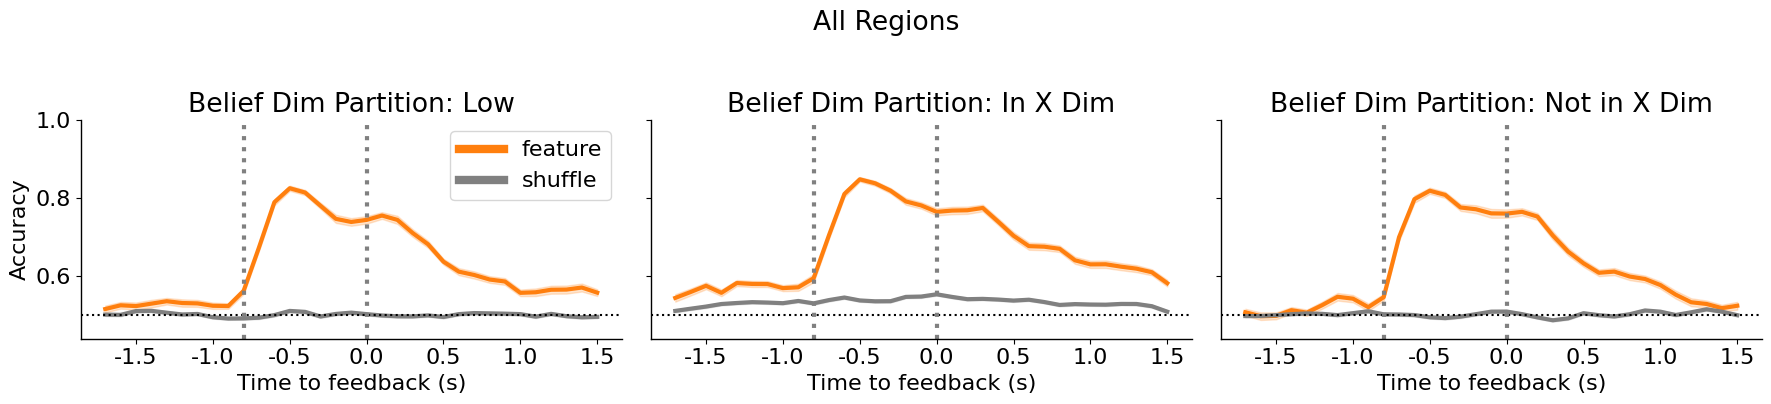

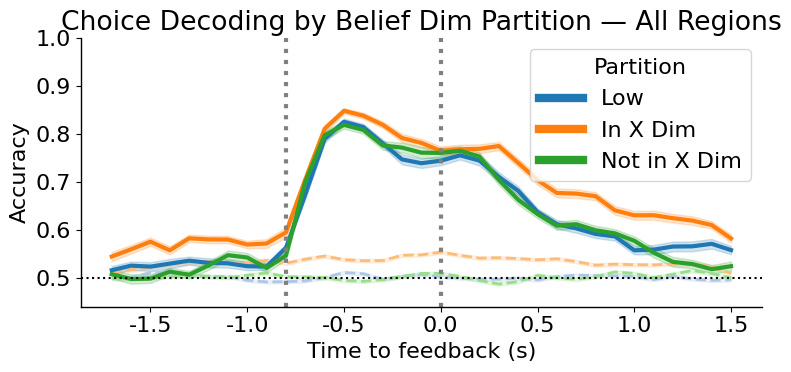

=== AMY ===


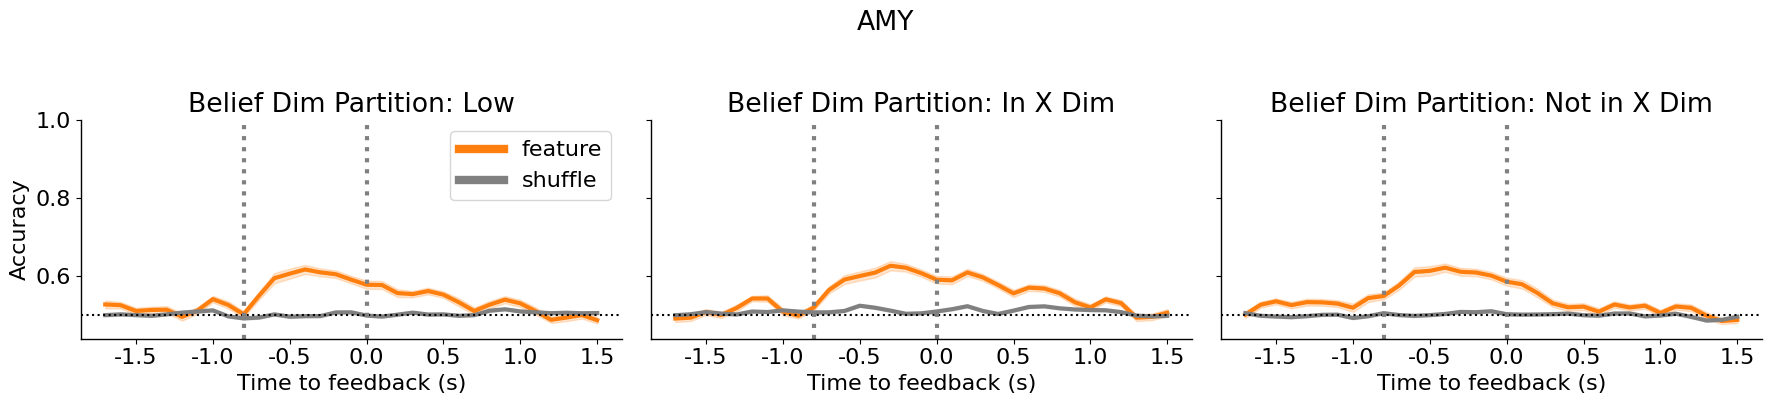

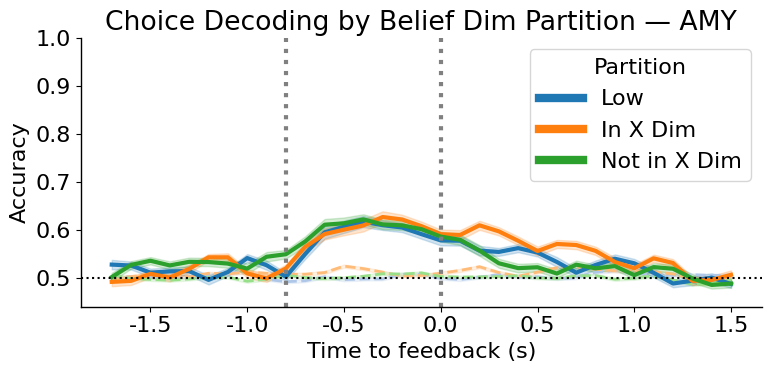

=== DSTR ===


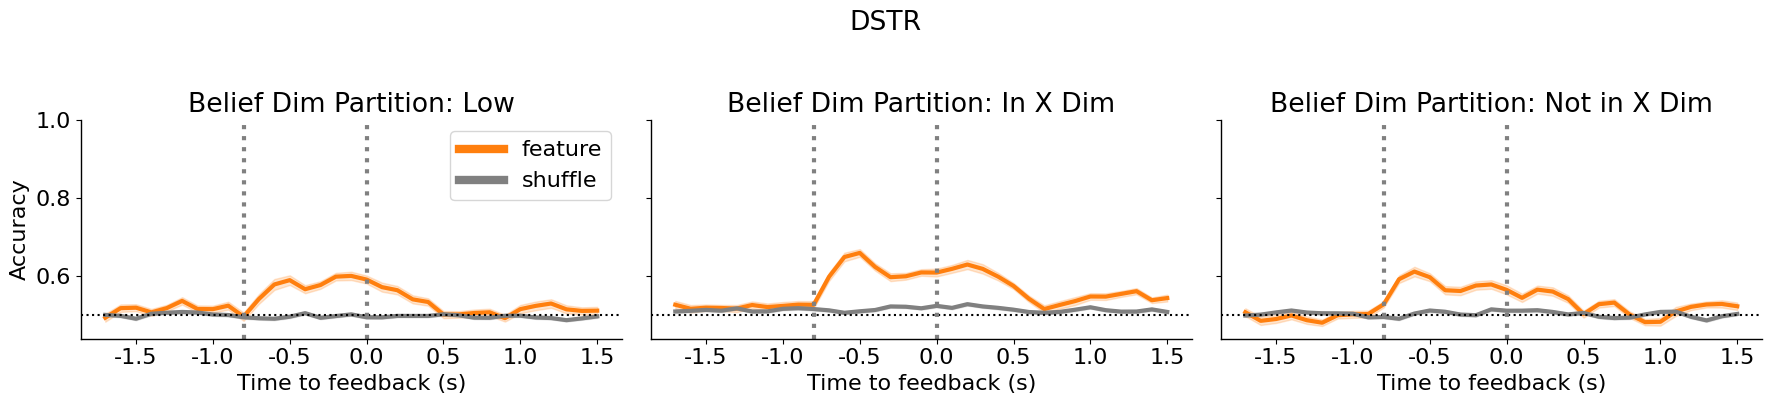

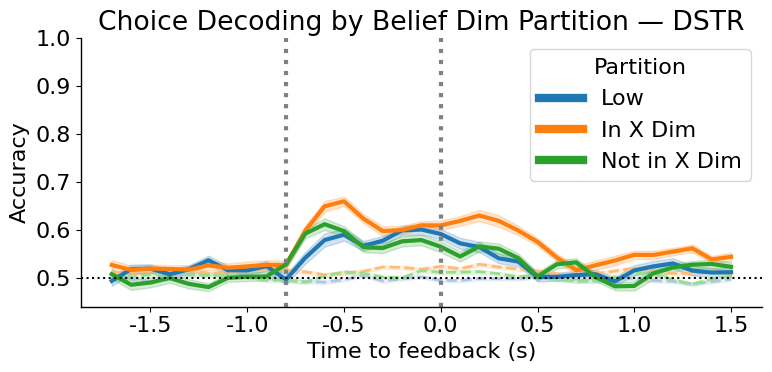

=== ITC ===


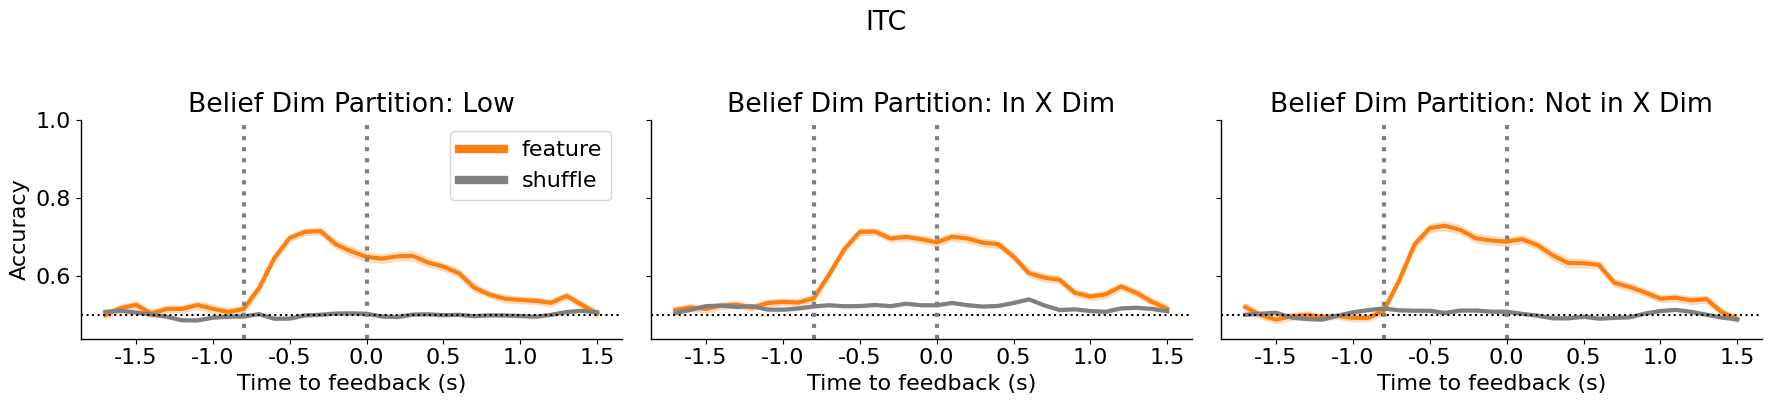

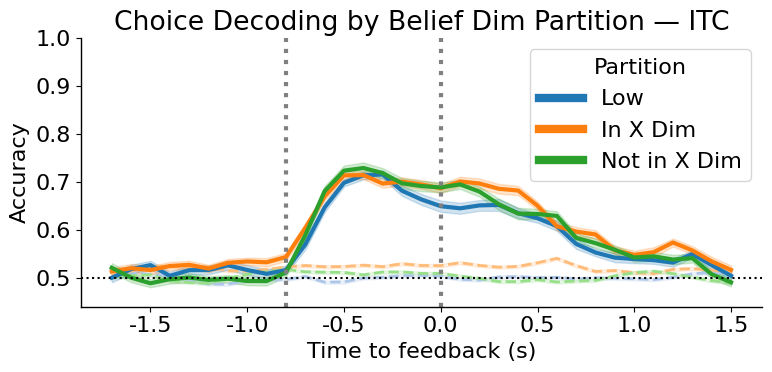

=== HC ===


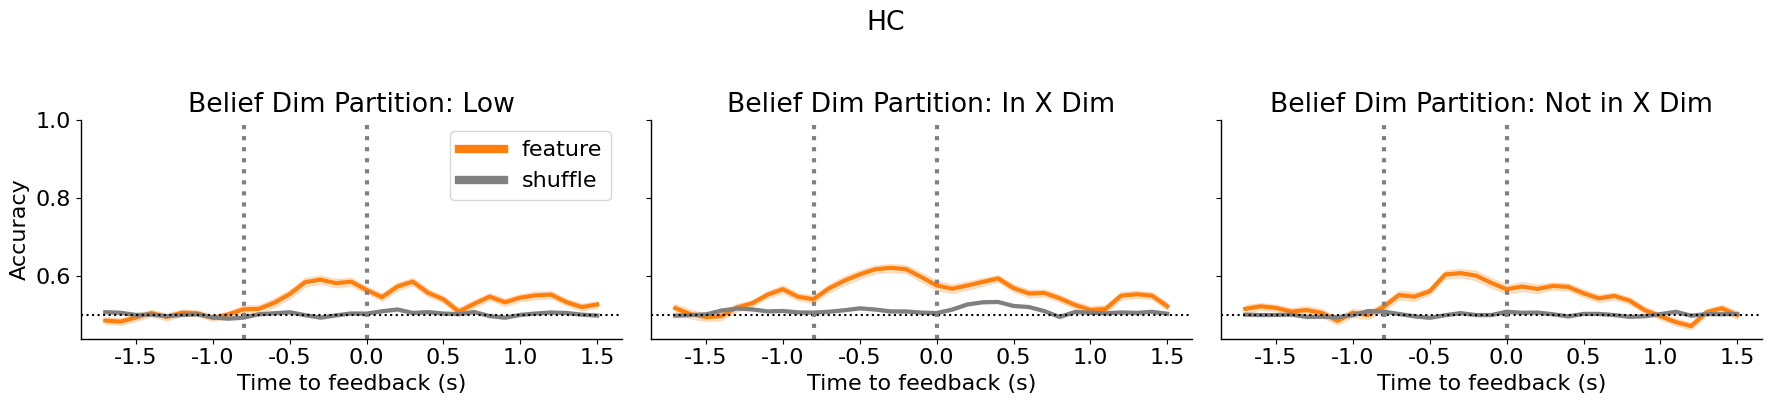

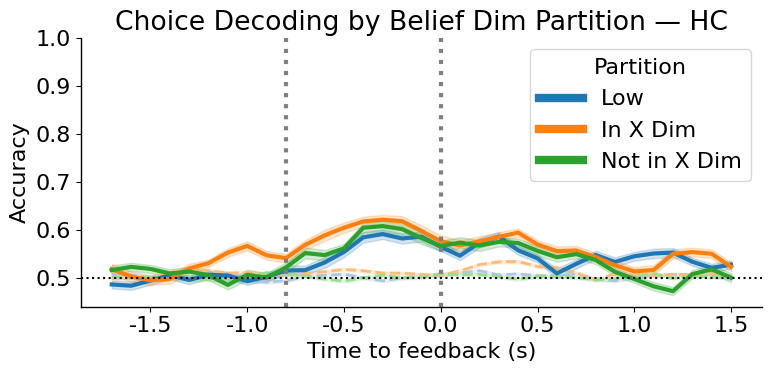

=== LPFC ===


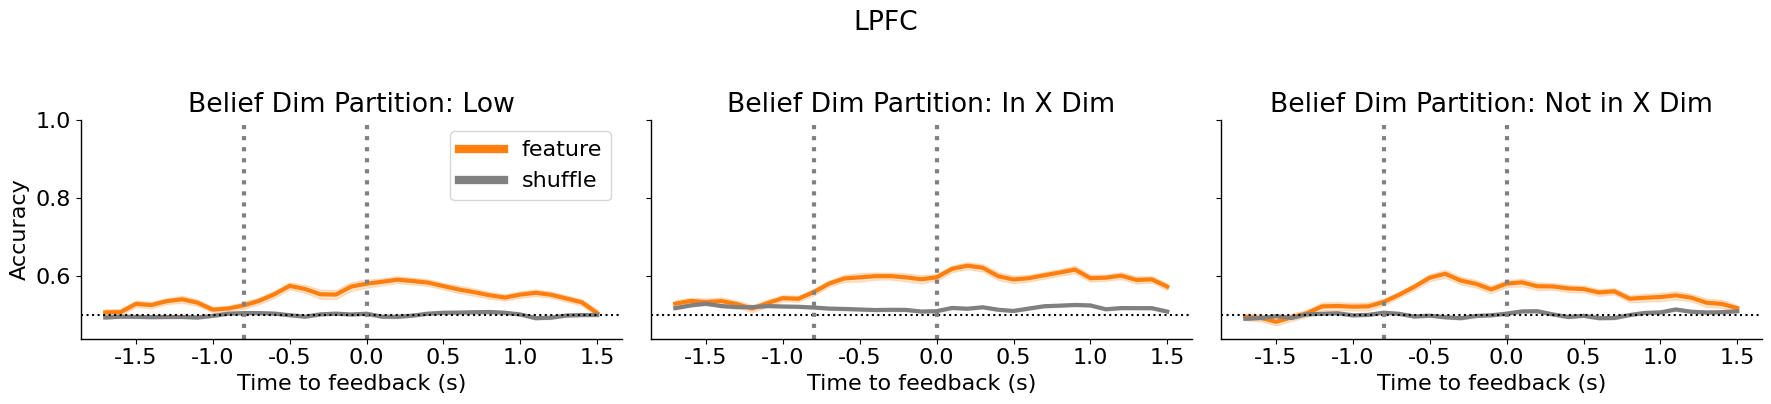

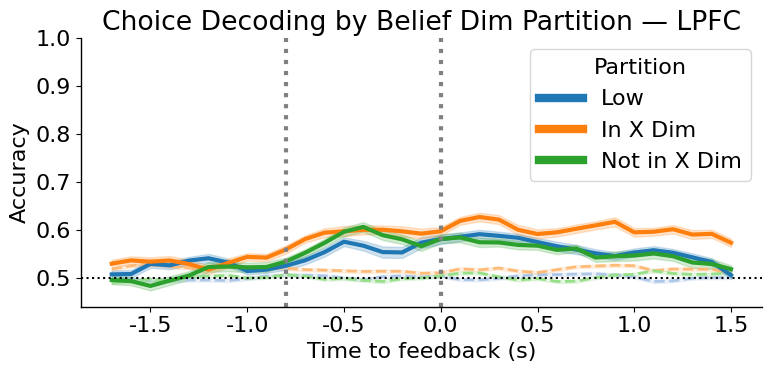

=== ACC ===


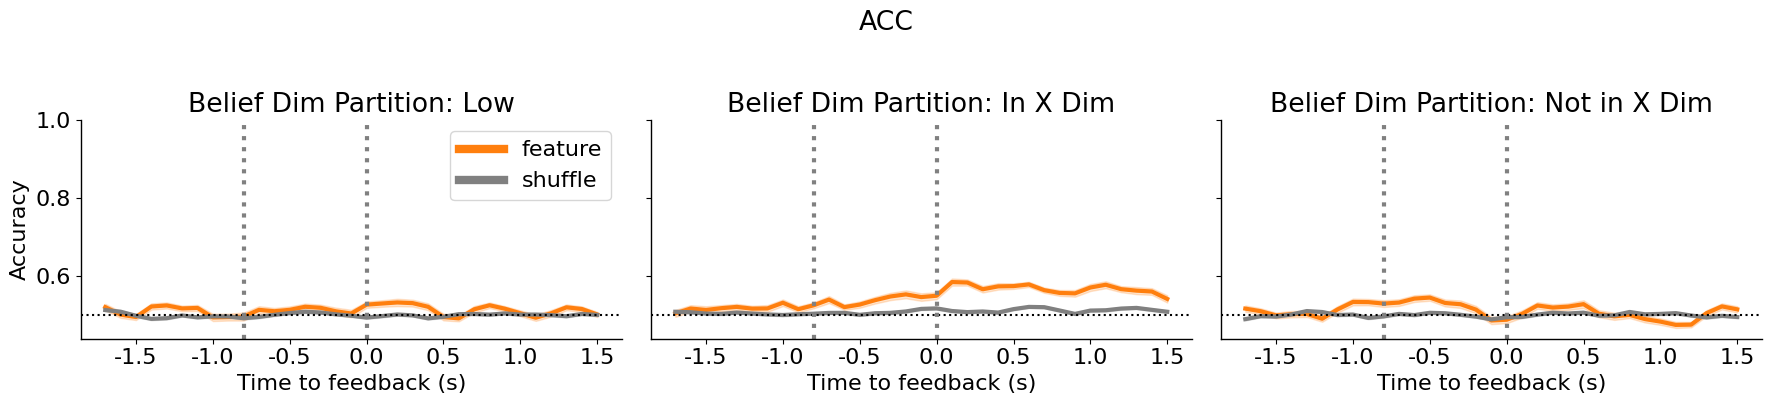

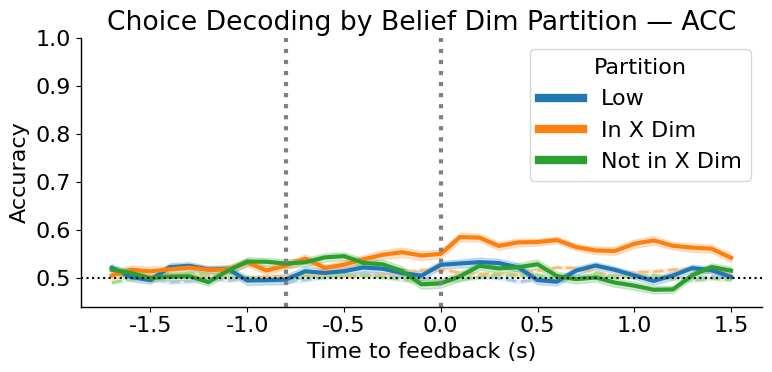

In [5]:
for region_level, regions, label in REGION_CONFIGS:
    print(f"=== {label} ===")
    all_res = load_partition_results(region_level, regions)
    plot_side_by_side(all_res, label=label)
    plt.show()
    plot_overlay(all_res, label=label)
    plt.show()